In [4]:
#Inicialización: borra todo y carga librerías (se pueden instalar fácilmente si no las tienen):
# install.packages("libreríaquequiero")

#Borra consola, variables y funciones definidas en el entorno Global
rm(list = setdiff(ls(), lsf.str()));
rm(list=lsf.str());
cat("\014")

#librerías, temas
suppressMessages(library("crayon")); suppressMessages(library("ggplot2"));
suppressMessages(library("gridExtra"));suppressMessages(library("latex2exp"))
library(xtable)
library(IRdisplay)
library(repr)

#opciones de ploteo ggplot2
temajuan3 <- theme(
    legend.title = element_text(size = 14),
    panel.background = element_rect(fill = "gray93"),
    legend.box = "vertical",
    legend.direction = "vertical",
    legend.key.height = unit(0.1,"snpc"),
    legend.key.width  = unit(0.1,"snpc"),
    axis.line = element_line(size = 0.5, lineend = "square"),
    axis.ticks = element_line(size = 1, colour = "black"),
    panel.border = element_rect(size = 1, fill = NA ),
    axis.title = element_text(size = 32),
    axis.text.x  = element_text(size = 28),
    axis.text.y = element_text(size = 28),
    legend.background = element_blank(),
    legend.position = c(0.3,0.8),
    legend.key = element_blank(),
    legend.text = element_text(size = 20),
    plot.title = element_text(size = 24)
    )
source("/home/juan/Documentos/Rfunj/temajuan2.R")
fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }
setwd("/home/juan/Documentos/Docencia/fexpi/")
fig(20,12)


Attaching package: ‘IRdisplay’


The following object is masked from ‘package:xtable’:

    display




## 1. Teorema del Límite Central - Versión Lyapunov

Sean $X_1,X_2,X_3,...,X_n$ variables aleatorias \textit{independientes}, cada una con media finita $\mu_i$ y varianza finita y mayor que cero $\sigma^2_i$.

Definimos:
\begin{equation}
s_n^2 = \sum_{i = 1}^n \sigma^2_i
\end{equation}

\noindent entonces, para $n \rightarrow \infty$:
\begin{equation}
\dfrac{1}{s_n} \sum_{i = 1}^n (X_i - \mu_i) \approx \mathcal{N}(0,1)
\end{equation}

* Si se cumple la \textit{condición de Lyapunov} para un $\delta > 0$: Es una condición que limita el crecimiento de los momentos centrados de orden $2 + \delta$. Habitualmente es complicado de probar...y se intenta para $\delta = 1$.

\begin{equation}
\lim _{n\to \infty }{\frac {1}{s_{n}^{2+\delta }}}\sum _{i=1}^{n}  |\langle (X_{i}-\mu _{i})^{2+\delta \;} \rangle|=0
\end{equation}

#### ¿Qué  quiere decir esto?

Que sumando diferentes distribuciones llegamos a una normal, cuya media es la media de las distribuciones.

### Ejemplo: Pendulame

Un péndulo tiene periodo $T = 10 s$, pero pero pero:

* Interacciones incontrolables con corrientes de aire, que modelamos con una distribución uniforme, afectan al periodo.
* Medimos a mano, con lo que tenemos algo *parecido* a una distribución normal, que ensucia los periodos.
* El hilo del péndulo se estira, y tiene dos posiciones a las cuales el material del hilo presenta cierta "preferencia": dos gaussianas.

In [5]:
T <- 10;
aire <- runif(min = -1, max = 1, n = 10^4);
medir.a.mano <- rnorm(mean = 0, sd = 0.08, n = 10^4)
hilo.malo <- c(rnorm(n = 10^4/2, mean = -0.5, sd = 0.25), rnorm(n = 10^4/2, mean = 0.5, sd = 0.25))
the.unknown <- c(rexp(n = 10^4/2, rate = 2), - rexp(n = 10^4/2, rate = 2))

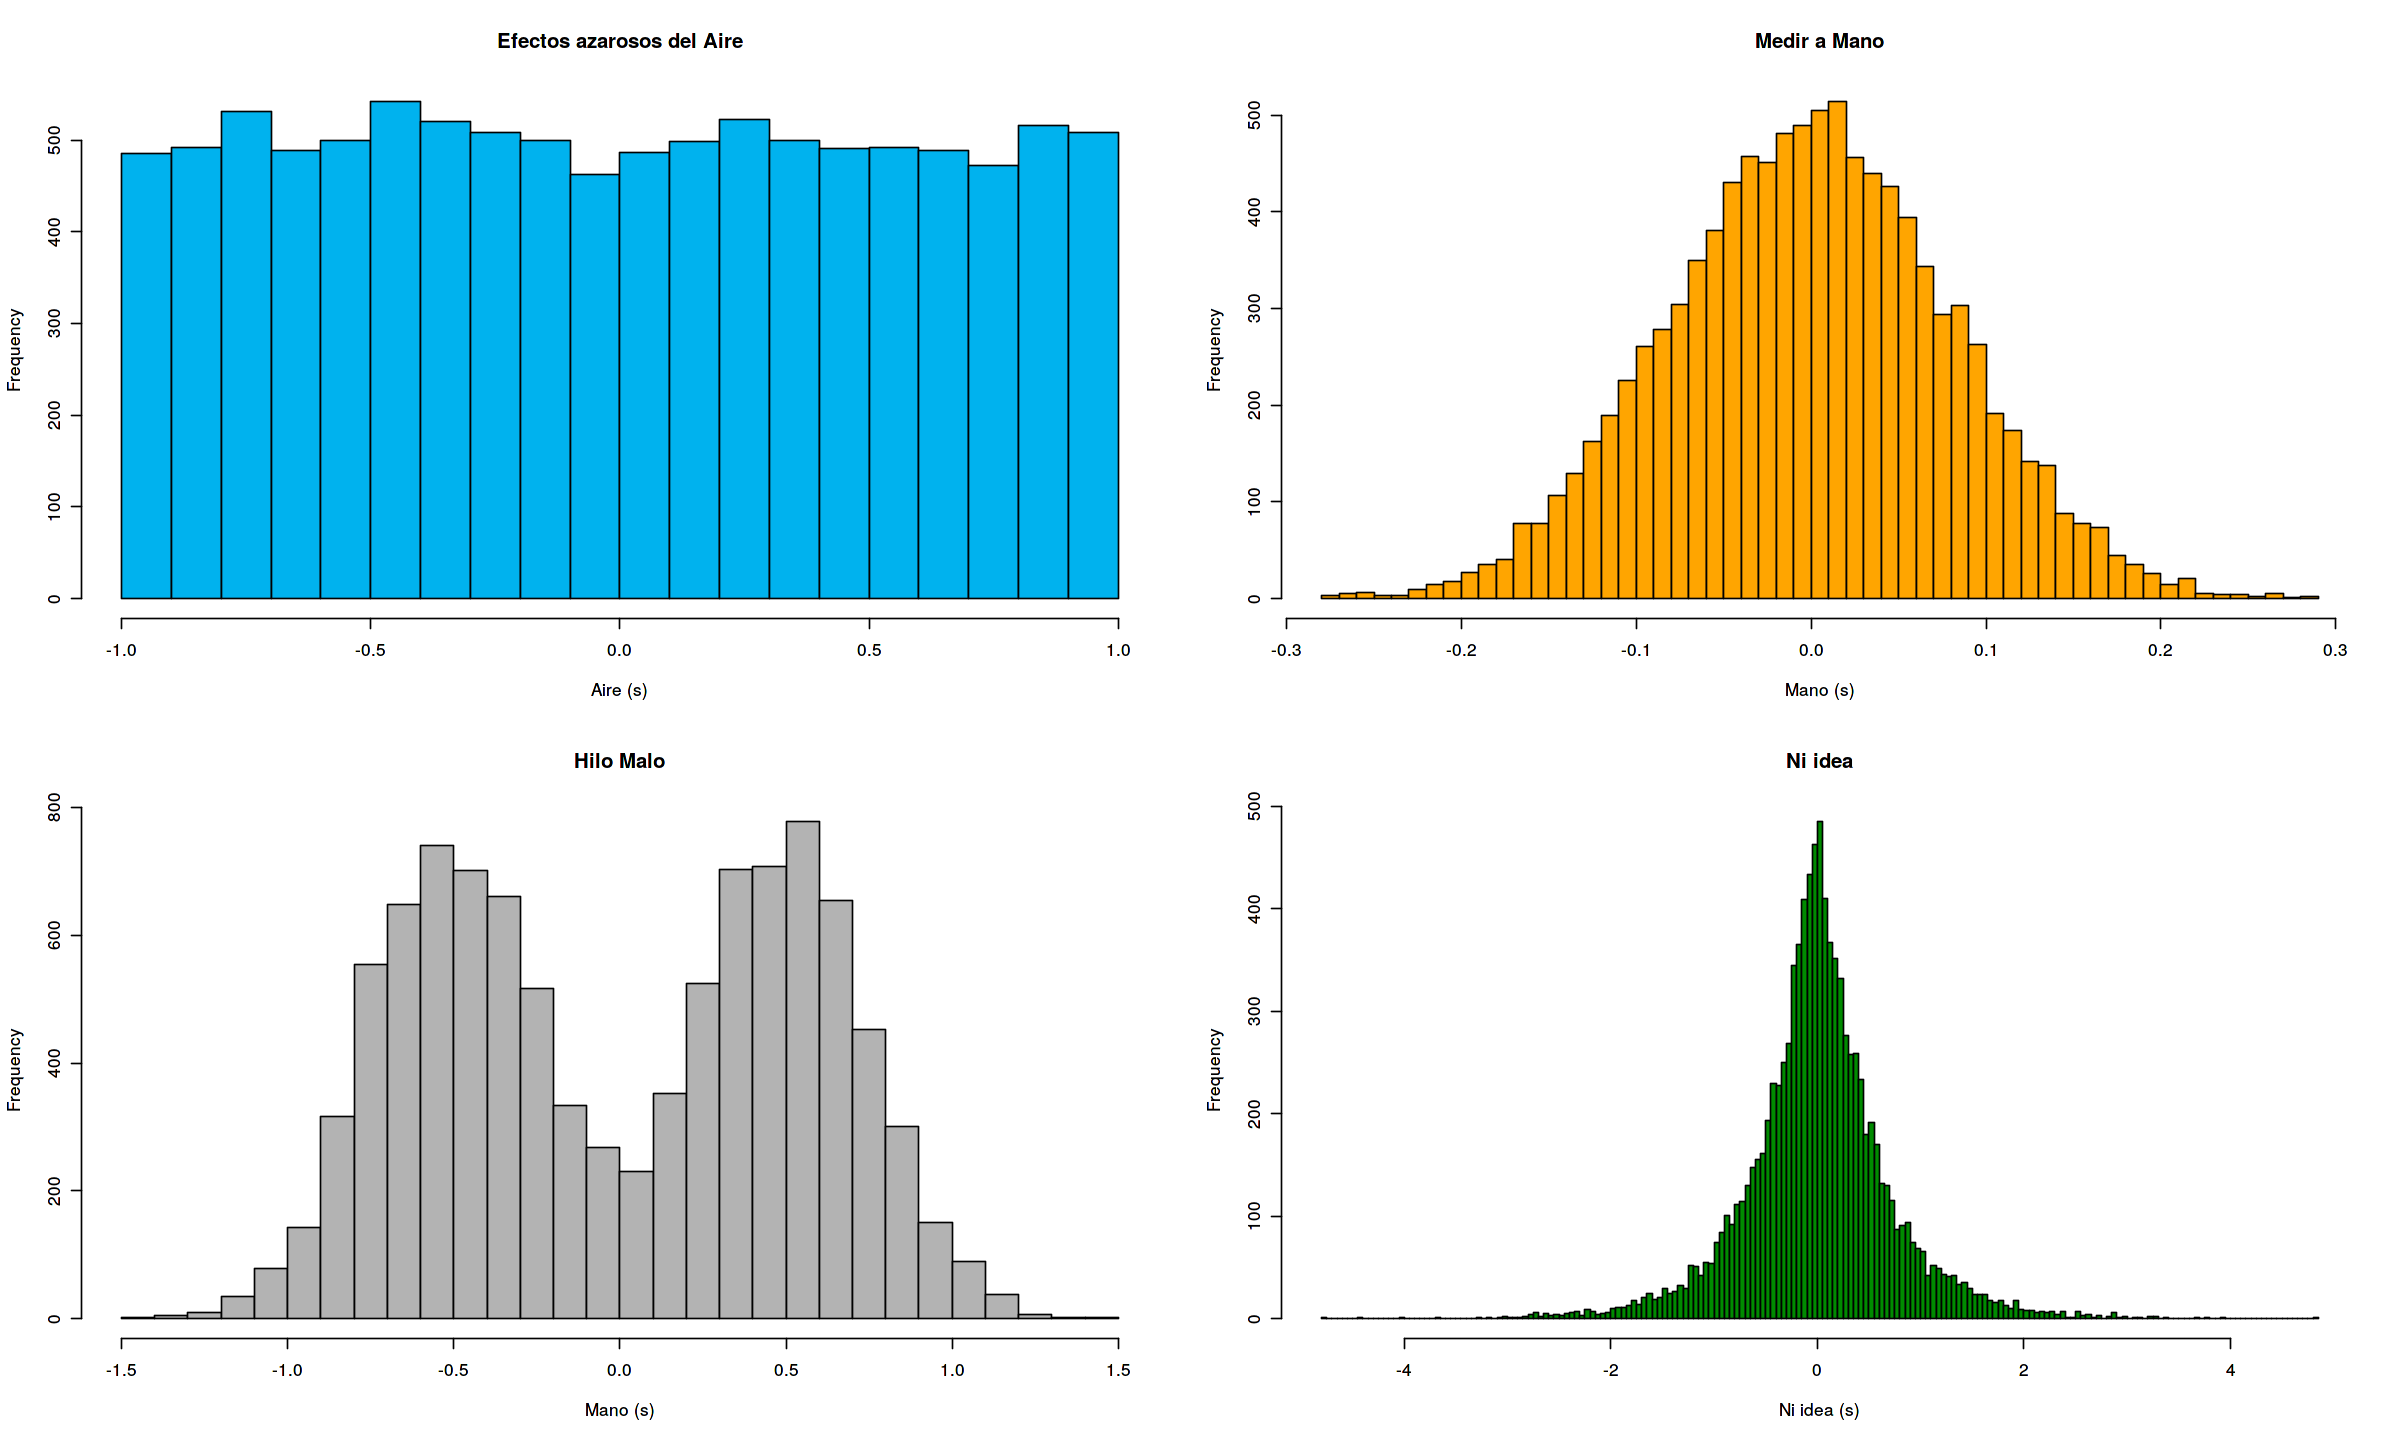

In [6]:
par(mfrow=c(2,2));fig(20,12); hist(aire, breaks = nclass.FD(aire), main = "Efectos azarosos del Aire", xlab = "Aire (s)", col = "Deepskyblue2")
hist(medir.a.mano, breaks = nclass.FD(medir.a.mano), main = "Medir a Mano", xlab = "Mano (s)", col = "Orange")
hist(hilo.malo, breaks = nclass.FD(hilo.malo), main = "Hilo Malo", xlab = "Mano (s)", col = "Gray70")
hist(the.unknown, breaks = nclass.FD(the.unknown), main = "Ni idea", xlab = "Ni idea (s)", col = "Green4")

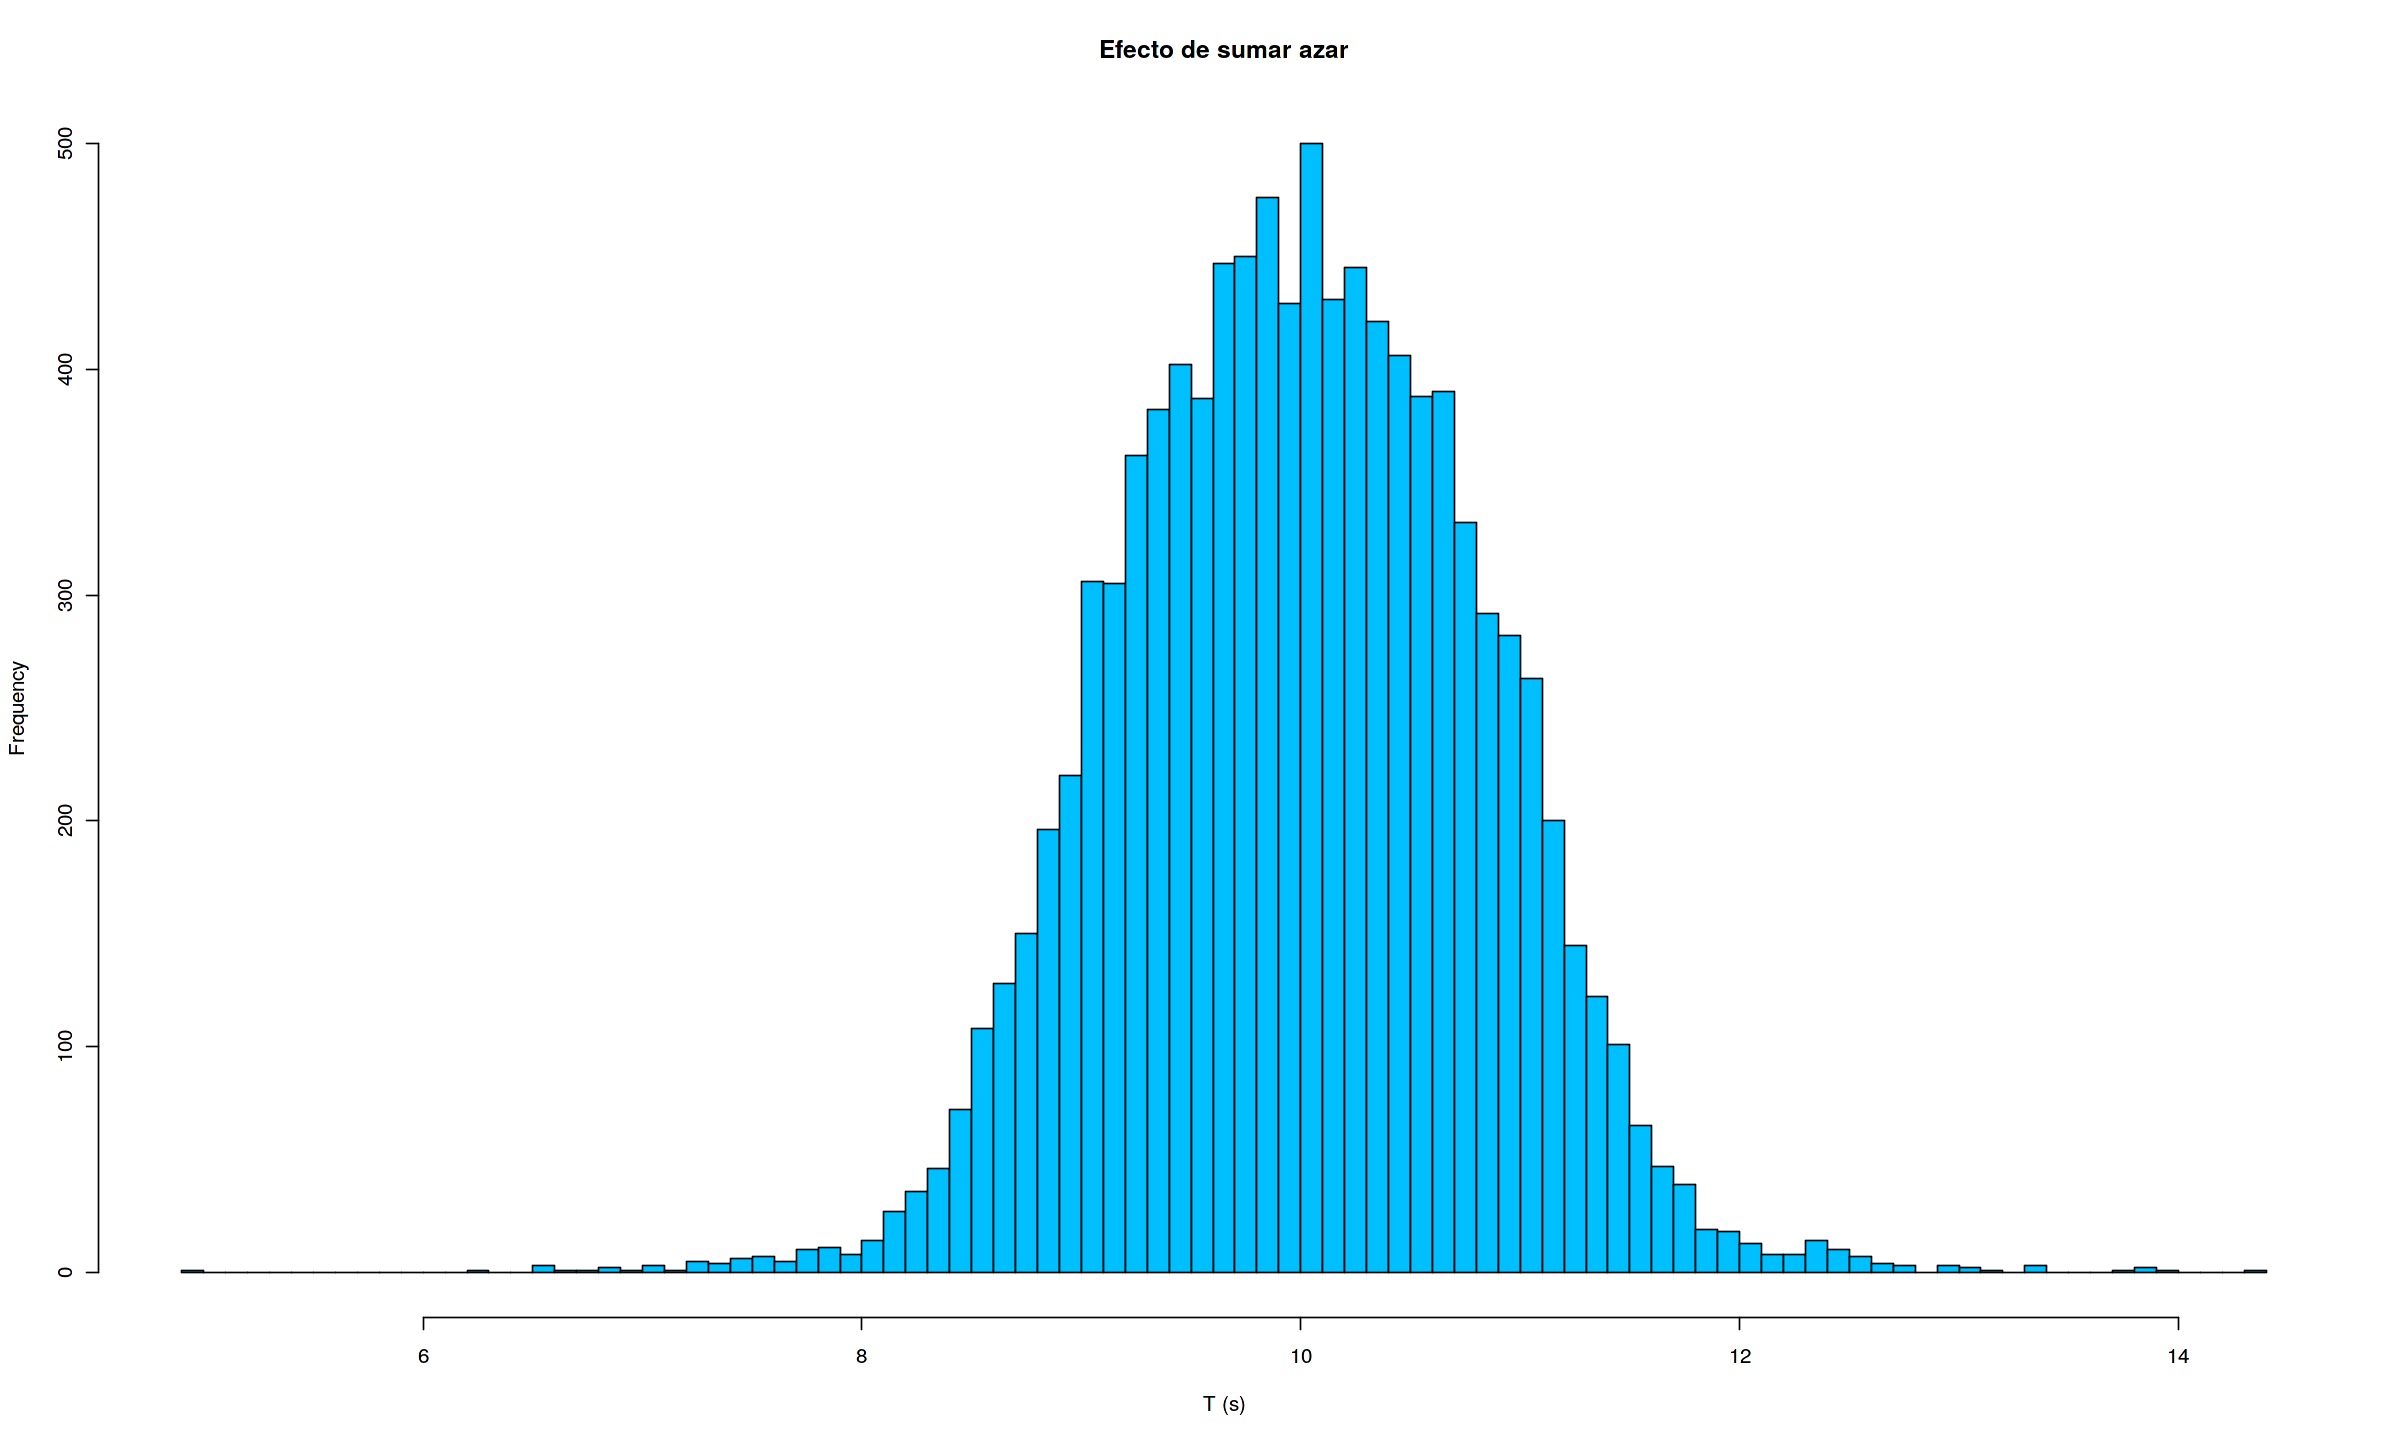

In [7]:
medida <- T + aire + medir.a.mano + hilo.malo + the.unknown; hist(medida, breaks = nclass.FD(medida), main = "Efecto de sumar azar",xlab = "T (s)",col = "DeepSkyblue")

Loading required package: MASS

Loading required package: survival



Fitting of the distribution ' norm ' by maximum likelihood 
Parameters:
       estimate  Std. Error
mean 10.0140040 0.008028047
sd    0.8028047 0.005676647

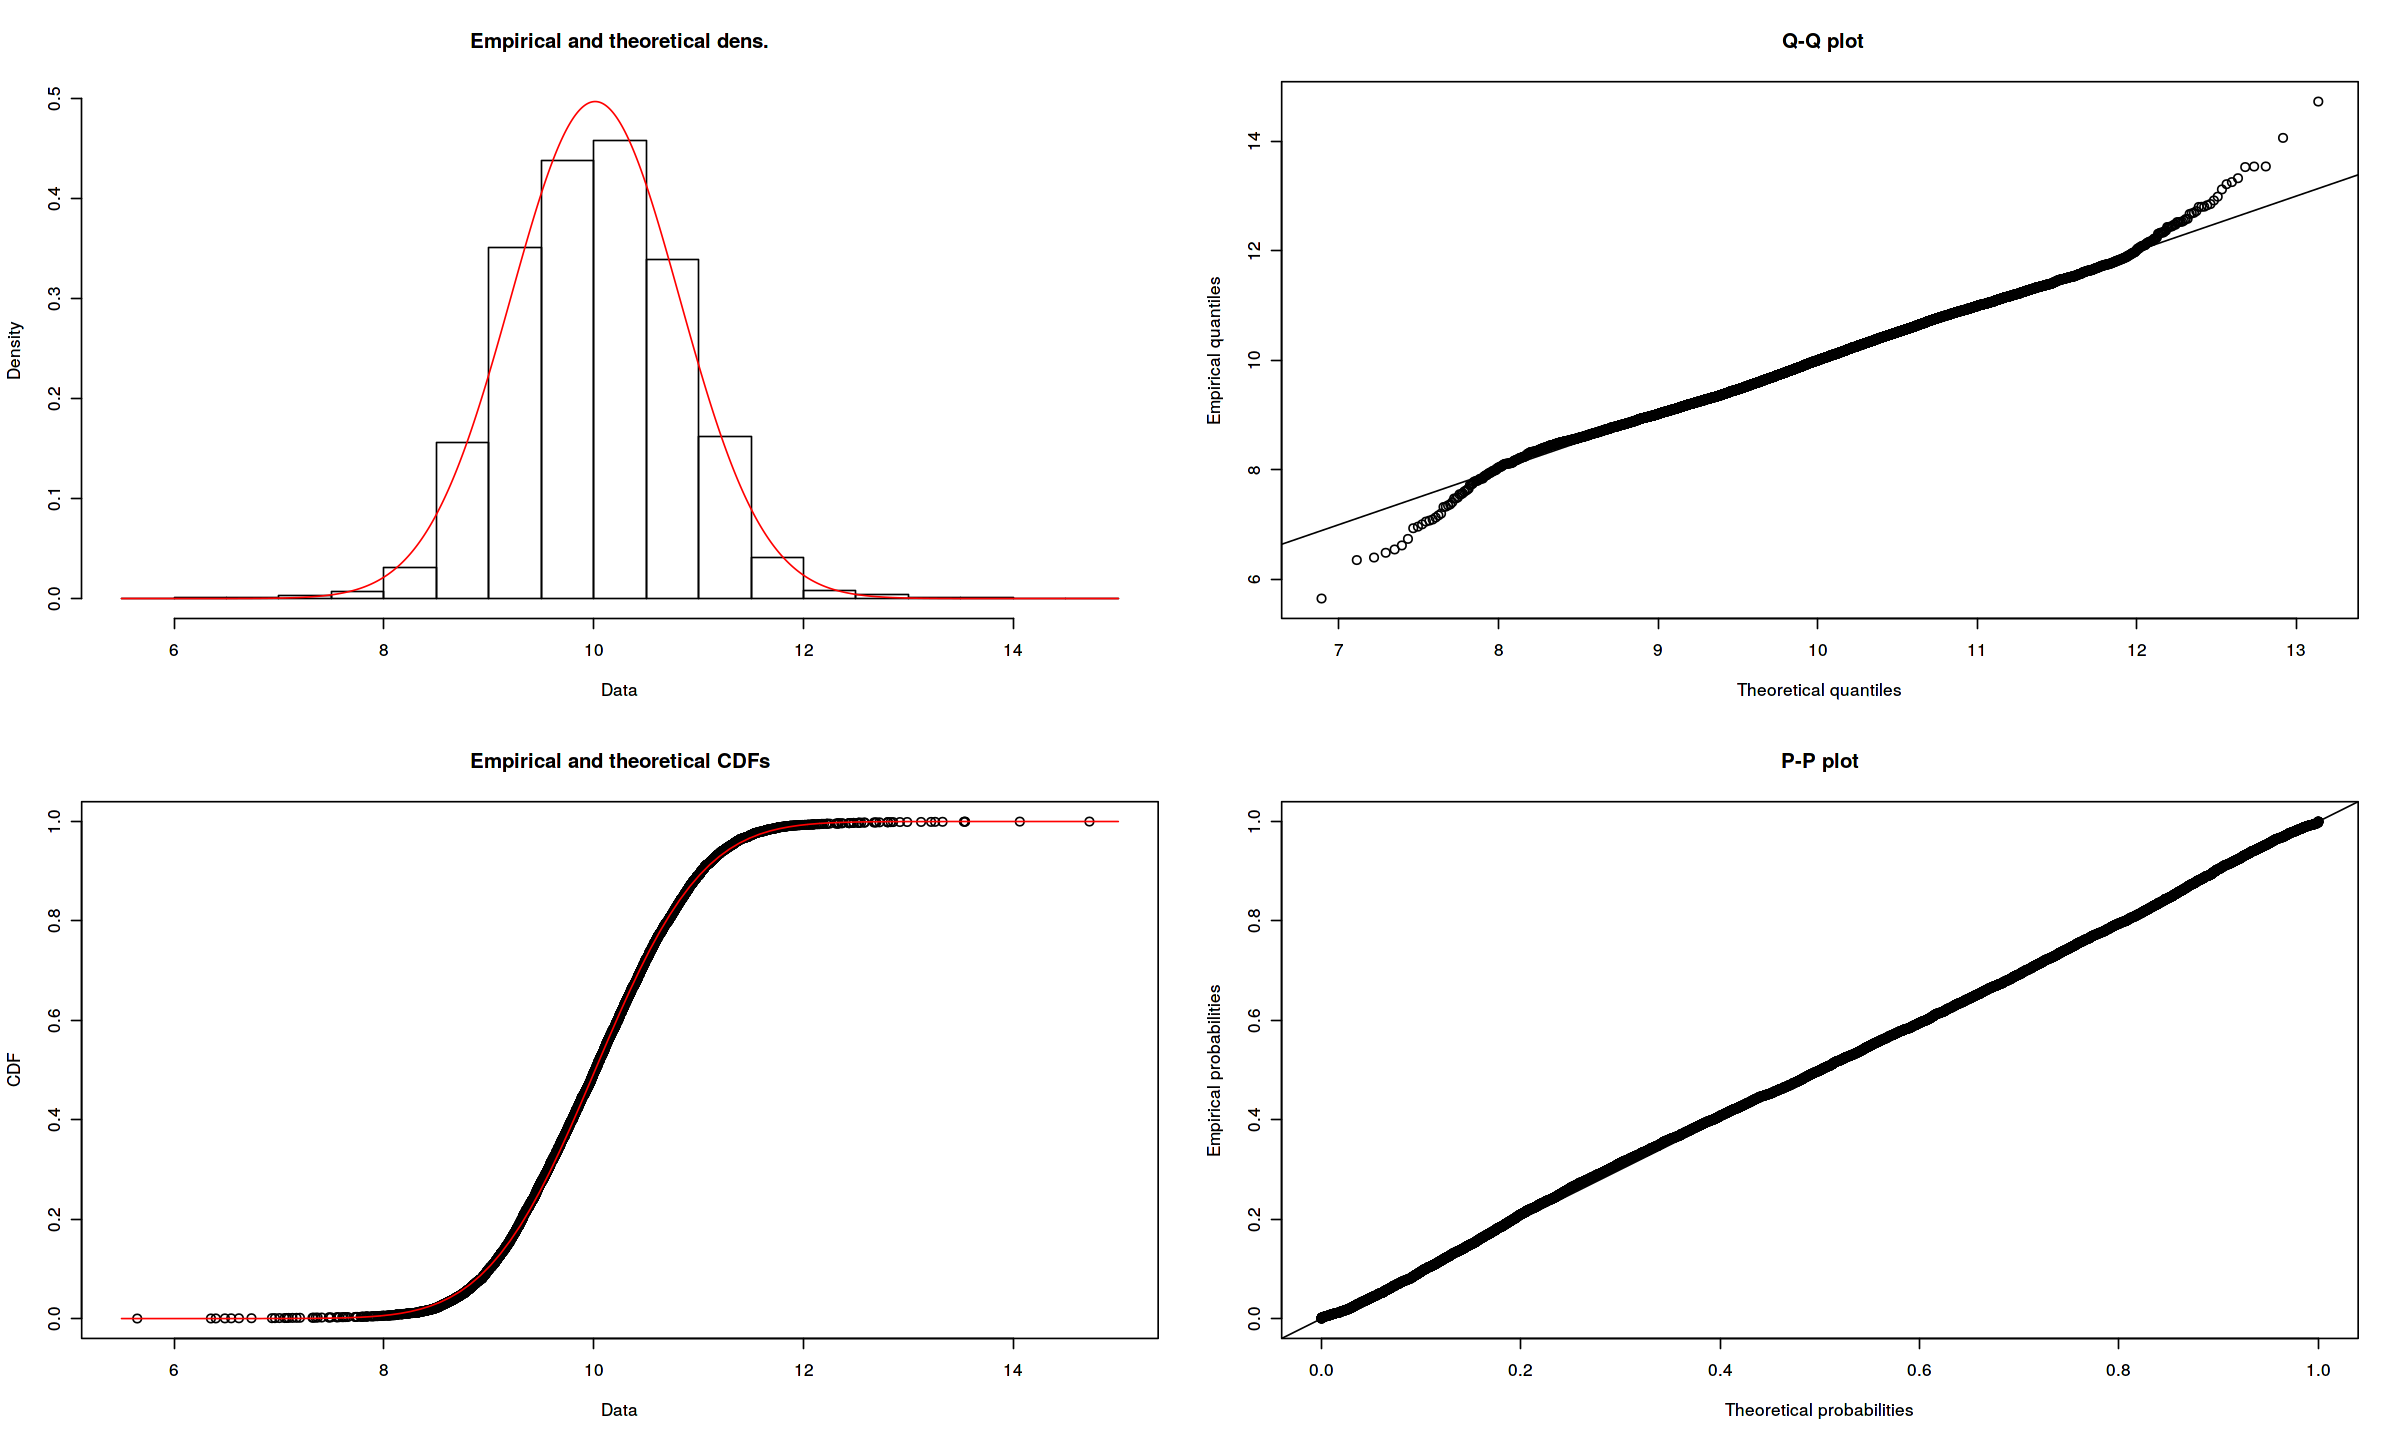

In [5]:
library("fitdistrplus")
ajuste.normal <- fitdist(medida, distr = "norm")
plot(ajuste.normal); ajuste.normal

### Cerrando Lyapunov

Como siempre, sumar muchas variables tiende a la normalidad. Esto podría explicar:

* La aparición (parición) de distribuciones normales por doquier.

* Que en experimentos aparezcan cantidades con distribución normal.

Lyapunov nos grita desde la tumba: "La suma de azares es normal". (ojo que esto no siempre es cierto)

## Teorema del clásico sabor limón.

Sean $X_1, X_2, X_3,.., X_N$, N variables aleatorias ***independientes e idénticamente distribuídas*** (IID), con distribuciones de probabilidad ***inespecificadas***, con media $\mu$ y varianza $\sigma^2$.

Entonces la media de la muestra $$\bar{X} =  \sum_{i = 1}^{N} X_i / N$$

tiene una distribución con media $\mu$ y varianza $\sigma^2/N$, que se aproxima a una normal a medida que $N\rightarrow \infty$

***Este teorema sirve para estimar medias***, en efecto:

***La variación de la media muestral es menor a medida que aumentamos el tamaño de la muestra***

**(ver gif TLClimon2.gif)** Ojo, que es pesadito.

## Ejemplo: midiendo g

Si tomamos unos valores de $g$ del acelerómetro, entonces tendremos una muestra de $g$, de tamaño arbitrario.



In [6]:
setwd("/home/juan/Documentos/Docencia/fexpi/2020/NTB/6.meansdTLC/denuevo/") #indica un nuevo directorio
g <- read.csv(file = "g.csv", sep = "\t", header = F)
g <- g$V1
class(g); head(g,3); length(g)

[1] "numeric"

[1] 9.893393 9.867675 9.895098

[1] 5150

### Vemos un histograma de las medidas

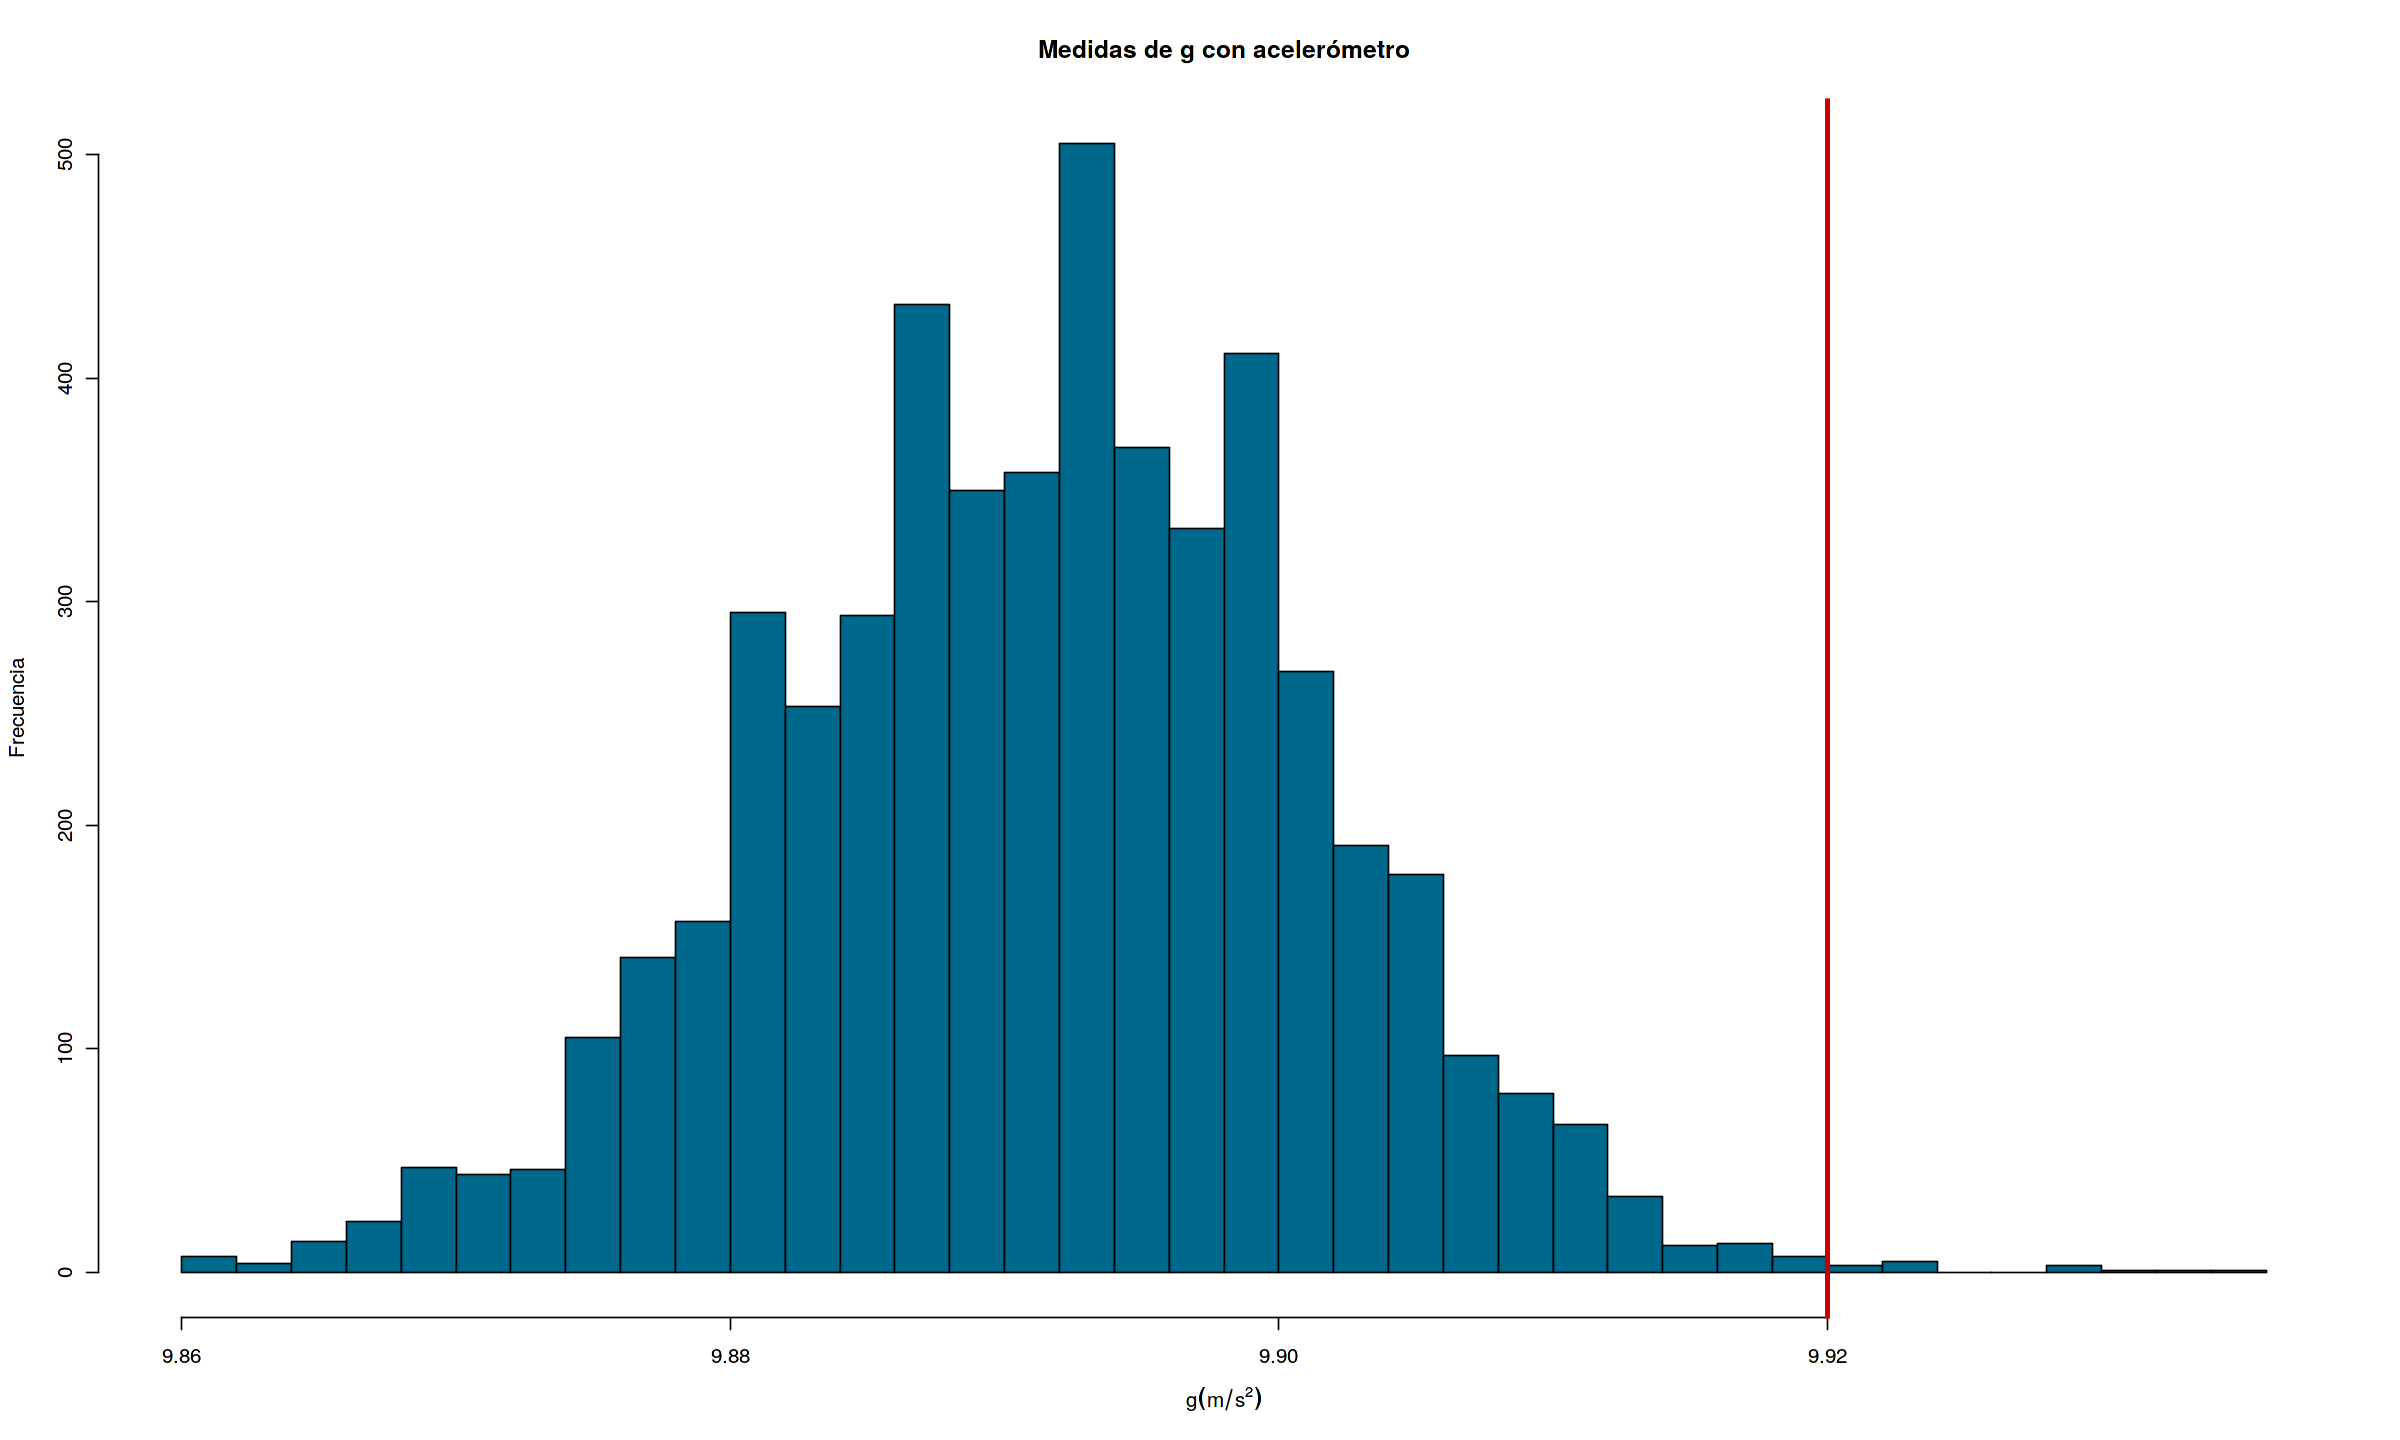

In [7]:
hist(g, breaks = nclass.FD(g),col = "Deepskyblue4", main = "Medidas de g con acelerómetro", xlab = expression(g(m/s^2)), ylab = "Frecuencia") 
abline(v = 9.92, col = "red3", lwd = 3)

Le ajustamos una $f(x)$ normal. Los saltitos en el gráfico P-P es el salto de la mínima escala del aparataje eléctrónico (un conversor A/D).

Ajusta muy bien...demasiado

Fitting of the distribution ' norm ' by maximum likelihood 
Parameters : 
        estimate   Std. Error
mean 9.891476466 1.363538e-04
sd   0.009785226 9.192355e-05
Loglikelihood:  16520.91   AIC:  -33037.81   BIC:  -33024.72 
Correlation matrix:
              mean            sd
mean  1.000000e+00 -3.077924e-13
sd   -3.077924e-13  1.000000e+00


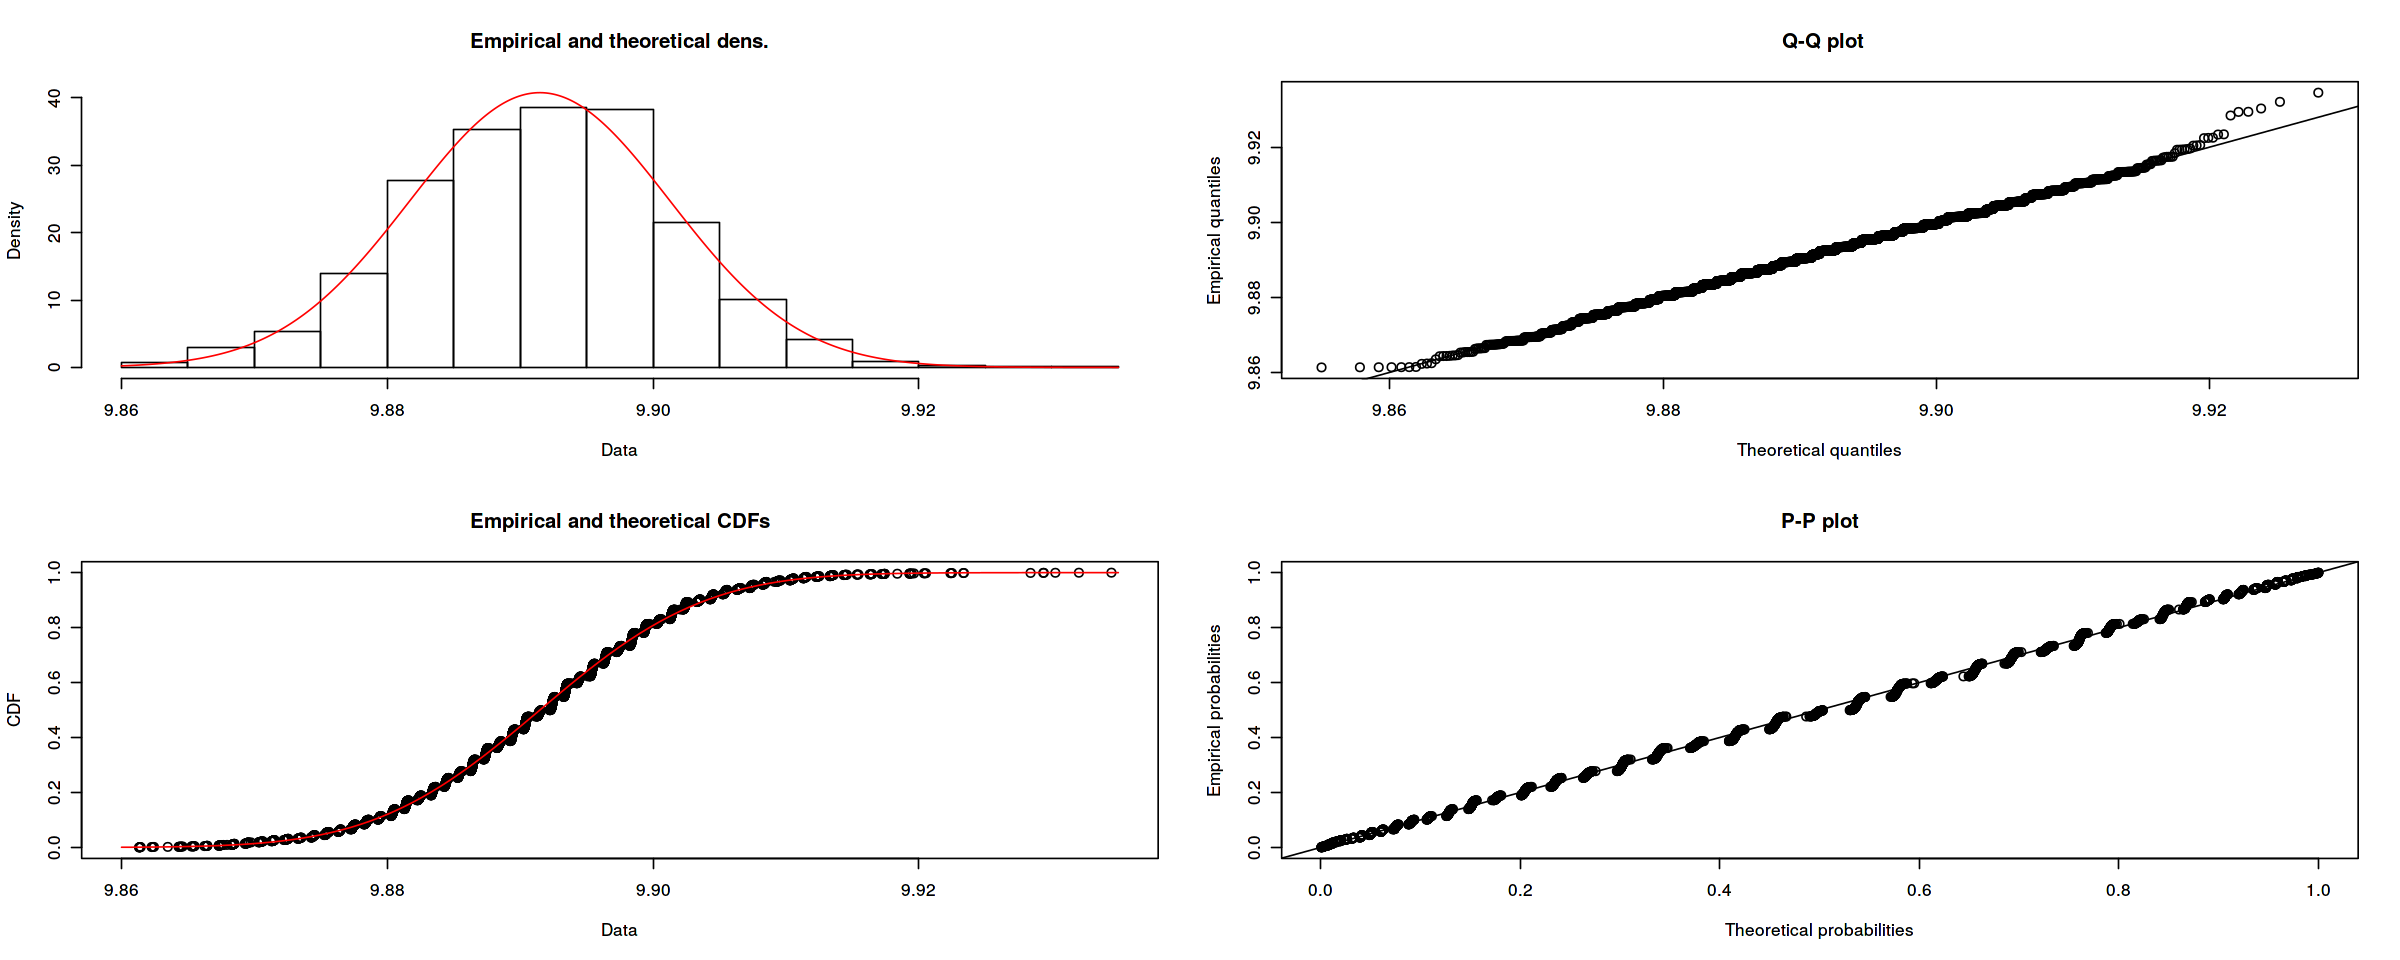

In [16]:
aju.normal <- fitdist(g, distr = "norm"); fig(20,8);plot(aju.normal); cat(bold("Ajusta muy bien...demasiado"))
summary(aju.normal)

#### Cantidades que sacamos a partir de los datos

In [9]:
mm <- mean(g); s <- sd(g); length(g);
cat(bold("La media muestral es mm = ", mm));
cat(bold("\nLa desviación estándar de la muestra es s = ", s));
cat(bold("\nEl tamaño de la muestra es  n = ", length(g)));

[1] 5150

La media muestral es mm =  9.89147646645521
La desviación estándar de la muestra es s =  0.00978617627897517
El tamaño de la muestra es  n =  5150

**Ya *lo sabemos* pero lo repetimos:**

* La media muestral nos limpia los ruidos posibles.

* La sd es una medida del ancho de la distribución respecto de la media (segundo momento centrado), pero pero pero:

   * ***Si es normal, sabemos los intervalos respecto de la media.***
   
   *  Puede significar el error de **una** (1) medida (claro, que, por supuesto, tenemos que medir muchas veces para estimar la sd)
   
Lo anterior quiere decir que, una vez estimada la sd a partir de una muestra grande, podemos saber *qué incerteza tendríamos si midiéramos* **una (1)** vez en las **mismas condiciones**.
   

### Vamos con la media $\mu$

Del TLC sabemos dónde ***vive*** la media muestral $\overline{g}$:

* Vive en una distribución normal, cuya media es igual a la media de la distribución $\mu$.

* Esa distribución normal tiene una desviación estándar que es $\sigma / \sqrt{n}$ ($\sigma$ es el ancho de la distribución de salida, no importa si es normal). $n$ es la cantidad de medidas que metemos en la media muestral.

A menos que hagamos un histograma de medias muestrales diferentes, no vamos a ver nunca la campana.



### Entonces:
* Aproximamos $\sigma$ con $s$.
* $\overline{g}$ es un valor de una distribución que no conocemos. Pero como sabemos el ancho:

$$P(\overline{g} - s/\sqrt{n} \leq \mu \leq \overline{g} + s/\sqrt{n}) \sim 68\% $$
$$P(\overline{g} - 2s/\sqrt{n} \leq \mu \leq \overline{g} + 2s/\sqrt{n}) \sim 95.4\% $$
$$P(\overline{g} - 3s/\sqrt{n} \leq \mu \leq \overline{g} + 3s/\sqrt{n}) \sim 99.7\% $$

# TAREA para ahora:

* Calcular la media $\mu$ y sus intervalos de confianza.

1. Cargar `g.csv`
1. Calcular el intervalo de confianza de $\mu$ para 1,2 y 3 $\sigma$

In [10]:
mg <- mean(g); abs(min(diff(g)))

[1] 0.04616186

sd(g)/sqrt(length(g)) -> dg

In [11]:
cat(bold("La media muestral es gbar = ", mean(g)));
cat(bold("\nLa desviación estándar de la muestra es s = ", s <- sd(g)));

La media muestral es gbar =  9.89147646645521
La desviación estándar de la muestra es s =  0.00978617627897517

In [12]:
cat(bold("La media teórica está entre", mg-s, "y", mg + s, "con ~ 68% de chances" ));
cat(bold("\nLa media teórica está entre", mg-2*s, "y", mg + 2*s, "con ~ 95.4% de chances" ));
cat(bold("\nLa media teórica está entre", mg-3*s, "y", mg + 3*s, "con ~ 99.7% de chances" ));
cat(bold("\n La desviación estándar de las medias muestrales será s", signif(s/sqrt(length(g)),1 )))

La media teórica está entre 9.88169029017623 y 9.90126264273418 con ~ 68% de chances
La media teórica está entre 9.87190411389725 y 9.91104881901316 con ~ 95.4% de chances
La media teórica está entre 9.86211793761828 y 9.92083499529213 con ~ 99.7% de chances
 La desviación estándar de las medias muestrales será s 1e-04

$$\vec{a} = a_x e_x + a_y e_y +a_z e_z $$

$$\vec{b} = b_x e_x + b_y e_y +b_z e_z $$

$$
a \cdot b = a_x b_x + a_y b_y + a_z b_z = |a| |b| cos(\alpha)
$$
